<a href="https://colab.research.google.com/github/manugiraldo123/Integracion-de-datos-y-prospectiva/blob/main/caso_riesgo_operacional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Simulación de Eventos de Riesgo Operacional (Nivel Individual)
Por: Manuela Giraldo y Sophia Mateus

## Caso de Estudio: Riesgo Operacional – FinanCred Solutions S.A.S.

FinanCred Solutions S.A.S. es una entidad financiera ficticia de crédito de consumo y microcrédito. Este notebook simula y analiza su riesgo operacional (errores en la originación y administración de créditos) bajo el enfoque **AMA (Basilea II)**, mediante la construcción de una Distribución Agregada de Pérdidas (LDA = Frecuencia × Severidad).

**Metodología:**
- **Simulación Poisson–Lognormal:** la Frecuencia mensual de eventos se modela como Poisson (conteo discreto e independiente), y la Severidad por evento como Lognormal, que captura la asimetría típica de las pérdidas financieras (muchos eventos de bajo costo, pocos muy altos).
- **Media:** estima la Pérdida Esperada (Expected Loss).
- **Varianza / Desviación estándar:** miden la dispersión y volatilidad de las pérdidas.
- **Asimetría:** evalúa si predominan eventos de bajo costo con una cola de eventos extremos.
- **Curtosis:** mide qué tan propensa es la distribución a generar pérdidas extremas frente a una normal.

In [ ]:
# 1. Importar librerías necesarias
import pandas as pd
import numpy as np
from scipy.stats import poisson, lognorm
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# 2. Fijar semilla aleatoria para reproducibilidad
np.random.seed(42)

### Simulación del Período y Frecuencia Mensual

In [ ]:
# 3. Simular un periodo histórico de 48 meses (4 años), desde enero de 2022 hasta diciembre de 2025
start_date = '2022-01-01'
end_date = '2025-12-31'

# Generar un rango de fechas mensuales
fechas_mes = pd.date_range(start=start_date, end=end_date, freq='MS')
num_meses = len(fechas_mes)

# 4. Para cada mes, generar el NÚMERO de eventos de riesgo operacional (Frecuencia mensual)
#    usando una distribución Poisson con lambda = 25
lambda_poisson = 25
frecuencia_mensual = poisson.rvs(lambda_poisson, size=num_meses)

# Asegurarse de que la frecuencia sea al menos 1 para simplificar la simulación de eventos individuales
frecuencia_mensual[frecuencia_mensual == 0] = 1 # O se podría omitir este paso si se maneja el caso de 0 eventos por mes

# Crear una lista para almacenar los eventos individuales
eventos_individuales = []

# Definir los parámetros para la simulación de severidad (Lognormal)
mean_severity = 4_500_000
std_severity = 6_000_000

# Calcular los parámetros mu y sigma para la distribución Lognormal
sigma_lognormal = np.sqrt(np.log(1 + (std_severity / mean_severity)**2))
mu_lognormal = np.log(mean_severity) - (sigma_lognormal**2) / 2

# Definir los rangos de recorte para la severidad
min_severity_clip = 500_000
max_severity_clip = 60_000_000

# Definir los tipos de evento y sus probabilidades
tipos_evento = [
    "Errores en validación documental",
    "Errores de digitación",
    "Desembolsos incorrectos",
    "Incumplimiento de procedimientos internos",
    "Deficiencias en controles operativos"
]
probabilidades_tipo = [0.35, 0.25, 0.15, 0.15, 0.10]

evento_id_counter = 0

### Simulación de Eventos Individuales (`df_eventos`)

In [ ]:
# Iterar sobre cada mes para generar eventos individuales
for i, fecha_mes in enumerate(fechas_mes):
    num_eventos_este_mes = frecuencia_mensual[i]

    for _ in range(num_eventos_este_mes):
        # 5. Simular el costo (Severidad) para CADA evento individual
        severidad = np.random.lognormal(mean=mu_lognormal, sigma=sigma_lognormal, size=1)[0]

        # 6. Recortar o truncar los valores simulados de severidad
        severidad_clipped = np.clip(severidad, min_severity_clip, max_severity_clip)

        # 7. Asignar a cada evento individual un Tipo_Evento aleatorio
        tipo_evento = np.random.choice(tipos_evento, p=probabilidades_tipo)

        eventos_individuales.append({
            'ID_Evento': evento_id_counter,
            'Fecha_Mes': fecha_mes,
            'Tipo_Evento': tipo_evento,
            'Severidad_COP': severidad_clipped
        })
        evento_id_counter += 1

# 8. Construir el DataFrame df_eventos con una fila por CADA evento individual
df_eventos = pd.DataFrame(eventos_individuales)

# 9. Verificar con un print() que el número total de filas de df_eventos sea mayor a 1000
num_filas_df_eventos = len(df_eventos)
print(f"Número total de eventos individuales (df_eventos): {num_filas_df_eventos}")
if num_filas_df_eventos > 1000:
    print("Verificación exitosa: El número de filas de df_eventos es mayor a 1000.")
else:
    print("Advertencia: El número de filas de df_eventos NO es mayor a 1000. Considere ajustar los parámetros de simulación.")

Número total de eventos individuales (df_eventos): 1186
Verificación exitosa: El número de filas de df_eventos es mayor a 1000.


### Visualización de Datos Generados

In [ ]:
# 11. Mostrar df_eventos.head(10), df_mensual.head(10), y las estadísticas descriptivas de ambas tablas con .describe()

# Formato de visualización: números completos, sin notación científica, con separador de miles
pd.options.display.float_format = '{:,.0f}'.format

print("\n--- Primeras 10 filas de df_eventos (eventos individuales) ---")
display(df_eventos.head(10))

print("\n--- Estadísticas descriptivas de df_eventos ---")
display(df_eventos.describe())



--- Primeras 10 filas de df_eventos (eventos individuales) ---


,ID_Evento,Fecha_Mes,Tipo_Evento,Severidad_COP
0,0,2022-01-01,Incumplimiento de procedimientos internos,"2,978,365"
1,1,2022-01-01,Incumplimiento de procedimientos internos,"7,187,381"
2,2,2022-01-01,Errores en validación documental,"1,327,954"
3,3,2022-01-01,Errores de digitación,"1,938,785"
4,4,2022-01-01,Errores en validación documental,"3,642,100"
5,5,2022-01-01,Errores de digitación,"3,515,276"
6,6,2022-01-01,Errores en validación documental,"645,739"
7,7,2022-01-01,Errores en validación documental,"1,764,870"
8,8,2022-01-01,Errores de digitación,"2,293,845"
9,9,2022-01-01,Desembolsos incorrectos,"4,061,910"



--- Estadísticas descriptivas de df_eventos ---


,ID_Evento,Fecha_Mes,Severidad_COP
count,"1,186",1186,"1,186"
mean,592,2024-01-04 12:07:17.099494144,"4,560,889"
min,0,2022-01-01 00:00:00,"500,000"
25%,296,2023-01-01 00:00:00,"1,434,092"
50%,592,2024-02-01 00:00:00,"2,831,905"
75%,889,2025-01-01 00:00:00,"5,350,348"
max,"1,185",2025-12-01 00:00:00,"60,000,000"
std,343,NaN,"5,339,577"


### Exportación a CSV

In [ ]:
# 12. Exportar ambas tablas a CSV
file_eventos_individuales = "FinanCred_eventos_individuales.csv"
df_eventos.to_csv(file_eventos_individuales, index=False)
print(f"\nDataFrame df_eventos exportado a '{file_eventos_individuales}'")



DataFrame df_eventos exportado a 'FinanCred_eventos_individuales.csv'


#Se define la base de datos y se visualiza


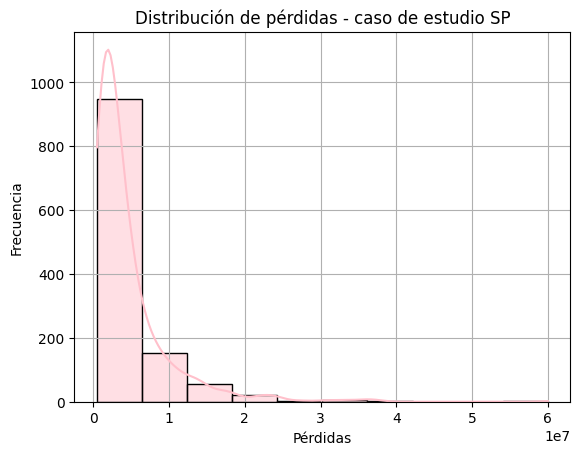

In [ ]:
nxl = "/content/FinanCred_eventos_individuales.csv"
XDB = pd.read_csv(nxl)

# 'Severidad_COP' es la columna que contiene las pérdidas individuales
LDA = XDB['Severidad_COP']

plt.figure()
sns.histplot(LDA,color='pink',bins=10, kde=True)
plt.title('Distribución de pérdidas - caso de estudio SP')
plt.xlabel('Pérdidas')
plt.ylabel('Frecuencia')
plt.grid()
plt.show()

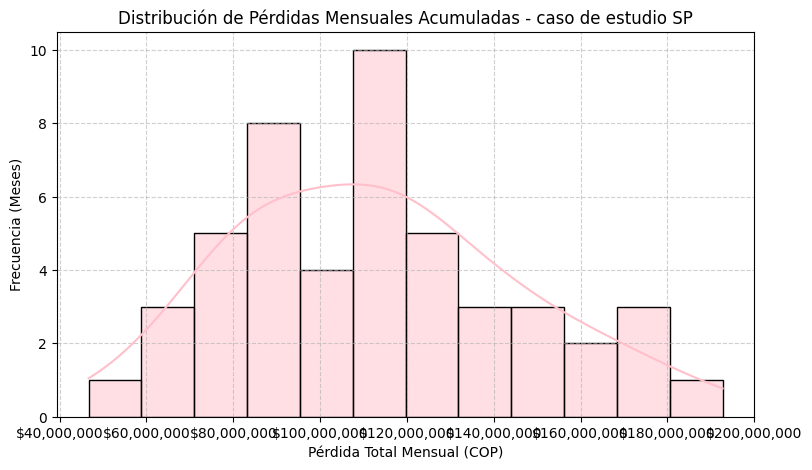

In [ ]:
#Agrupar por mes para calcular la Frecuencia y la Pérdida Total Mensual
df_mensual = XDB.groupby('Fecha_Mes').agg(
    Frecuencia=('ID_Evento', 'count'),
    Perdida_Total_COP=('Severidad_COP', 'sum')
).reset_index()

#Graficar la distribución de la Pérdida Total Mensual (LDA)
plt.figure(figsize=(9, 5))
sns.histplot(df_mensual['Perdida_Total_COP'], color='pink', bins=12, kde=True)

plt.title('Distribución de Pérdidas Mensuales Acumuladas - caso de estudio SP')
plt.xlabel('Pérdida Total Mensual (COP)')
plt.ylabel('Frecuencia (Meses)')

# Formato de moneda para el eje X
plt.gca().xaxis.set_major_formatter('${x:,.0f}')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#Se construye el histograma de frecuencias

In [ ]:
LDA = XDB['Severidad_COP']

NI = 10 #numero de intervalos en los cuales quiero agrupar los datos
counts,limits= np.histogram(LDA, bins= NI) #agrupar los datos en el numero de intervalos
LI =limits[:-1]
LS = limits[1:]
fi = fi = np.round(counts / sum(counts), 4) #porcentaje de datos por intervalos
MC = (LI+LS)/2  #marca de clase: dato representativo de cada intervalo



df = pd.DataFrame(np.column_stack((LI,LS,counts,fi, MC))) # limite inferior, superior y numero de datos en el intervalo
df.columns=["LI","LS","ND","fi","MC"]
display(df)

,LI,LS,ND,fi,MC
0,"500,000","6,450,000",947,1,"3,475,000"
1,"6,450,000","12,400,000",152,0,"9,425,000"
2,"12,400,000","18,350,000",54,0,"15,375,000"
3,"18,350,000","24,300,000",20,0,"21,325,000"
4,"24,300,000","30,250,000",3,0,"27,275,000"
5,"30,250,000","36,200,000",6,0,"33,225,000"
6,"36,200,000","42,150,000",3,0,"39,175,000"
7,"42,150,000","48,100,000",0,0,"45,125,000"
8,"48,100,000","54,050,000",0,0,"51,075,000"
9,"54,050,000","60,000,000",1,0,"57,025,000"


#Medidas de tendencia central

A. Medidas de tendencia central realizadas con fórmulas para mayor presición en los datos.


In [ ]:
# 1. Media
u = LDA.mean()
print("La media de las pérdidas es:", u)

# 2. Varianza y Desviación Estándar
varc = LDA.var()
sigma = LDA.std()
print("La varianza es:", varc)
print("La desviación estándar es:", sigma)

# 3. Intervalo de variación (95% empírico o +/- 2 sigmas)
lim_inf = u - 2 * sigma
lim_sup = u + 2 * sigma
print("El límite inferior es:", lim_inf)
print("El límite superior es:", lim_sup)

# 4. Coeficiente de Asimetría (Skewness)
cas = LDA.skew()
print("El coeficiente de asimetría es:", cas)

# 5. Coeficiente de Curtosis (Kurtosis)
kurt = LDA.kurt()
print("El coeficiente de curtosis es:", kurt)

La media de las pérdidas es: 4560889.373516375
La varianza es: 28511082671772.734
La desviación estándar es: 5339577.012439537
El límite inferior es: -6118264.6513626985
El límite superior es: 15240043.398395449
El coeficiente de asimetría es: 3.3994555561614472
El coeficiente de curtosis es: 18.16860786713763


B. Medidas de tendencia central realizadas de manera manual considerando los 10 intervalos inicialmente establecidos


In [ ]:
#1. Media - Valor esperado de una pérdida (que es lo mas comun?)
u= np.sum(MC*fi)
print("la media de las pérdidas es:", u)

#2. Varianza - Indica que tan dispersos están los datos alrededor de la media
varc = np.sum(((MC-u)**2)*fi)
print("La varianza es:", varc)

sigma = np.sqrt(varc) #desviación estandar
print("La desviación estandar es:", sigma)

#3. Intervalo de variación de las pérdidas
#en este intervalo se toman dos sigmas para encontrar el 95% de los datos
#todos los datos fuera de este intervalo se conocen como outliers
print("el limite inferior es:", u-2*sigma)
print("el limite superior es:", u+2*sigma)

#4. coeficiente de asimetria
cas= np.sum(((MC-u)**3)*fi)/((sigma**3))
print("el coeficiente de asimetria es:", cas)

#5. coeficiente de curtosis
curtosis = (np.sum(((MC - u)**4) * fi) / (sigma**4)) - 3
print("el coeficiente de curtosis es:", curtosis)

la media de las pérdidas es: 5424220.0
La varianza es: 23977342891600.0
La desviación estandar es: 4896666.508105285
el limite inferior es: -4369113.016210569
el limite superior es: 15217553.01621057
el coeficiente de asimetria es: 3.8903724913240705
el coeficiente de curtosis es: 21.530481202070202


In [ ]:
from google.colab import files

# Guardar y descargar automáticamente
XDB.to_excel("Base_Datos_Severidad_LDA.xlsx", index=False)
files.download("Base_Datos_Severidad_LDA.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Resumen ejecutivo

Teniendo en cuenta el casod e estudi planteado sobre la entidad financiera Financred solutions se realizo el siguiente procedimiento para cumplir el objetivo del caso de estudio

1. Configuración Inicial y Preparación de Librerías:

Se importaron las librerías necesarias para el ejercicio como lo son pandas, numpy, scipy.stats, matplotlib.pyplot y seaborn para la manipulación de datos, simulación estadística y visualización.
Asi mismo se establecio una semilla aleatoria (np.random.seed(42)) para asegurar la reproducibilidad de la simulación, y que los datos no cambiaran en ningun momento.

CREACION Y PREPARACION DE LA BASE DE DATOS PARA EL CASO DE ESTUDIO

2. Definición del Período y Simulación de Frecuencia Mensual:

Se estableció un período histórico de 48 meses (4 años), desde enero de 2022 hasta diciembre de 2025.
Se simuló la frecuencia mensual de eventos de riesgo operacional utilizando una distribución Poisson con un parámetro lambda = 25, lo que significa que en promedio se esperan 25 eventos por mes.

3. Simulación de Eventos Individuales y su Severidad:

Para cada evento individual, se simuló su severidad (costo en COP) utilizando una distribución Lognormal. Los parámetros de esta distribución se calcularon a partir de una severidad media objetivo de $4.5M y una desviación estándar de $6M.
Se aplicó un recorte a la severidad simulada, asegurando que los valores estuvieran entre $500 mil y $60 millones COP.
A cada evento se le asignó aleatoriamente un tipo de evento (e.g., "Errores en validación documental", "Desembolsos incorrectos", ETC) basado en probabilidades predefinidas.
Se creó el DataFrame df_eventos, que contiene un total de 1186 eventos individuales simulados, cada uno con su ID_Evento, Fecha_Mes, Tipo_Evento y Severidad_COP.

4. Visualización Inicial y Exportación de Datos:

Se verificó que el número de eventos individuales superara las 1000 filas.
Se mostró un resumen del DataFrame df_eventos.
Se exportó el DataFrame df_eventos a un archivo CSV llamado FinanCred_eventos_individuales.csv.

5. Carga de Datos y Análisis de Distribución de Severidad Individual:

Se cargó el archivo CSV FinanCred_eventos_individuales.csv en un nuevo DataFrame XDB para su análisis.
Se extrajo la columna Severidad_COP en una variable LDA.
Se generó un histograma con la distribución de estas pérdidas individuales (LDA), que mostró una clara asimetría positiva, indicando la presencia de muchos eventos de baja severidad y una cola larga de eventos de alta severidad.

6. Agregación Mensual y Análisis de Distribución de Pérdidas Totales:

Se agrupó el DataFrame XDB por Fecha_Mes para calcular la frecuencia mensual (número de eventos) y la pérdida total mensual (Perdida_Total_COP).
Se generó un histograma de la Perdida_Total_COP mensual, visualizando cómo se distribuyen las pérdidas acumuladas a lo largo de los meses. Esta distribución también mostró una inclinacion o agrupacion hacia la derecha, con la mayoría de los meses registrando pérdidas entre $80 millones y $140 millones COP.

7. Análisis de Medidas Estadísticas Clave (Severidad Individual):

Se calcularon las principales medidas estadísticas sobre la Severidad_COP de los eventos individuales (LDA):

* **Media (Pérdida Esperada por evento)**: Aproximadamente $4.56 millones COP**.

* **Varianza:** Cerca de **$28.5 billones COP².

* **Desviación Estándar:** Aproximadamente $5.34 millones COP**, lo que indica una alta dispersión.

* **Intervalo de Variación:** Los valores se encuentran mayormente entre aproximadamente -$6.12 millones y $15.24 millones COP.

* **Coeficiente de Asimetría**: 3.40, confirmando una fuerte asimetría positiva (más eventos pequeños, pocos muy grandes).

* **Coeficiente de Curtosis**: 18.17, indicando una distribución con "colas pesadas", es decir, una mayor probabilidad de eventos extremos (pérdidas muy grandes) en comparación con una distribución normal.

Estas mismas medidas se calcularon de forma manual utilizando un agrupamiento en 10 intervalos, obteniendo resultados consistentes con los cálculos directos.

8. Exportación Final:

Finalmente, el DataFrame XDB fue exportado a un archivo Excel llamado Base_Datos_Severidad_LDA.xlsx y se habilitó su descarga automática.





## conclusiones

* Dominio de Eventos de Baja Severidad: La simulación confirma que la mayoría de los eventos de riesgo operacional son de bajo costo (Pérdida Esperada por evento alrededor de $4.56 millones COP).

* Potencial Significativo de Eventos Extremos: A pesar de lo anterior, la alta asimetría (3.40) y, especialmente, la alta curtosis (18.17) son las conclusiones más críticas. Esto indica que, aunque no son frecuentes existe una probabilidad considerable de que ocurran eventos de riesgo operacional con pérdidas extremadamente altas.

Alta Volatilidad en las Pérdidas:

* La desviación estándar de $5.34 millones COP para las pérdidas individuales es superior a la media, lo que indica la gran variabilidad o dispersión en la severidad de los eventos.

Variabilidad Mensual de las Pérdidas Totales:

* El histograma de Pérdidas Mensuales Acumuladas muestra que, aunque hay un rango típico de pérdidas (80 millones y 140 millones), también hay meses con pérdidas considerablemente más altas. Esto resalta la necesidad de capital y provisiones que no solo cubran la pérdida esperada promedio, sino también los picos de pérdidas inesperadas.

Implicaciones para la Gestión del Riesgo

* Necesidad de Capital para Pérdidas Inesperadas: Un coeficiente de curtosis tan elevado implica que FinanCred Solutions S.A.S. debe provisionar capital no solo para la pérdida esperada, sino también para las pérdidas inesperadas (Unexpected Loss) que se derivan de estos eventos extremos. El modelo AMA de Basilea II busca precisamente capturar este capital adicional necesario.

* Enfoque en Eventos Raros y de Alto Impacto: La dirección de la entidad debe prestar especial atención a la identificación, mitigación y preparación para los eventos de riesgo operacional de alta severidad, ya que, aunque comos se ha mencionado no son frecuentes, son los que pueden generar el mayor impacto financiero.
En conclusion el análisis revela que, si bien la mayoría de los errores son de bajo impacto, la estructura de riesgo de FinanCred Solutions S.A.S. está caracterizada por la existencia de eventos de cola pesada que, aunque raros, pueden resultar en pérdidas financieras importantes y deben ser el foco principal de la gestión y el capital regulatorio.